In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("retrospective_data_cleaned.csv")

df["YearMonth"] = pd.to_datetime(df["YearMonth"]).dt.to_period("M")
df = df.sort_values("YearMonth")

df.head()


,Commodities,Countries,Nominal_Value,HS_Code,Month,Year,Inflation_Rate,CPI,Real_Value,CategoryType,YearMonth
146,2846 Rare-earth Metal Compounds Of Yttrium Or ...,Malaysia,6007,2846,1,2010,1.5,100.0,6007.0,Compound,2010-01
348,7404 Copper Waste And Scrap,Singapore,29880,7404,1,2010,1.5,100.0,29880.0,Other,2010-01
4134,"7604 Aluminum Bars, Rods And Profiles",Malaysia,8010,7604,1,2010,1.5,100.0,8010.0,Other,2010-01
6044,"7612 Aluminum Casks, Cans Etc Nov 300 Liter Ca...",Thailand,3100,7612,1,2010,1.5,100.0,3100.0,Other,2010-01
5995,"7612 Aluminum Casks, Cans Etc Nov 300 Liter Ca...",Malaysia,3075,7612,1,2010,1.5,100.0,3075.0,Other,2010-01


In [2]:
#just summary stats for # of unique elements in certain cols 
print("Number of countries:", df["Countries"].nunique())
print("Number of commodities:", df["Commodities"].nunique())
print("Number of category types:", df["CategoryType"].nunique())

print("\nCategory counts:")
print(df["CategoryType"].value_counts())

print("\nCountry counts:")
print(df["Countries"].value_counts())

Number of countries: 11
Number of commodities: 54
Number of category types: 4

Category counts:
CategoryType
Other               5274
Refined/Articles    2749
Compound             189
Ore/Raw               26
Name: count, dtype: int64

Country counts:
Countries
Singapore      2694
Malaysia       1773
Thailand       1250
Philippines     987
Vietnam         843
Indonesia       615
Brunei           64
Cambodia          6
Burma             4
Laos              1
Timor-Leste       1
Name: count, dtype: int64


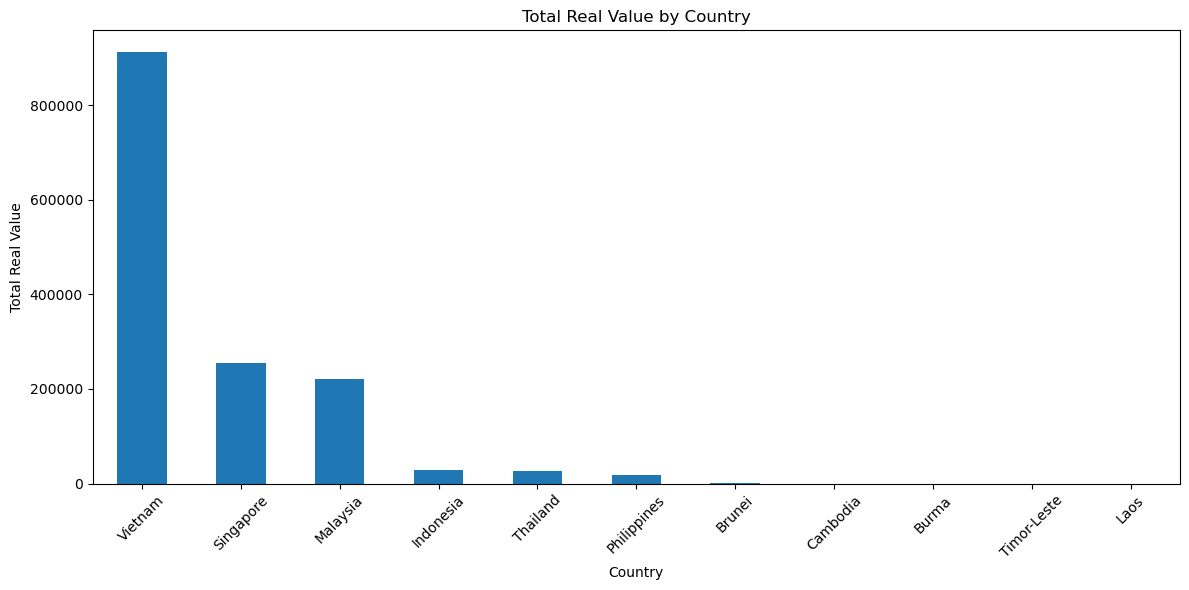

In [34]:

real_value_by_country_thousands = (
    df.groupby("Countries")["Real_Value"]
    .sum()
    .sort_values(ascending=False) / 1000
)

ax = real_value_by_country_thousands.plot(kind="bar")
ax.set_title("Total Real Value by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Total Real Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

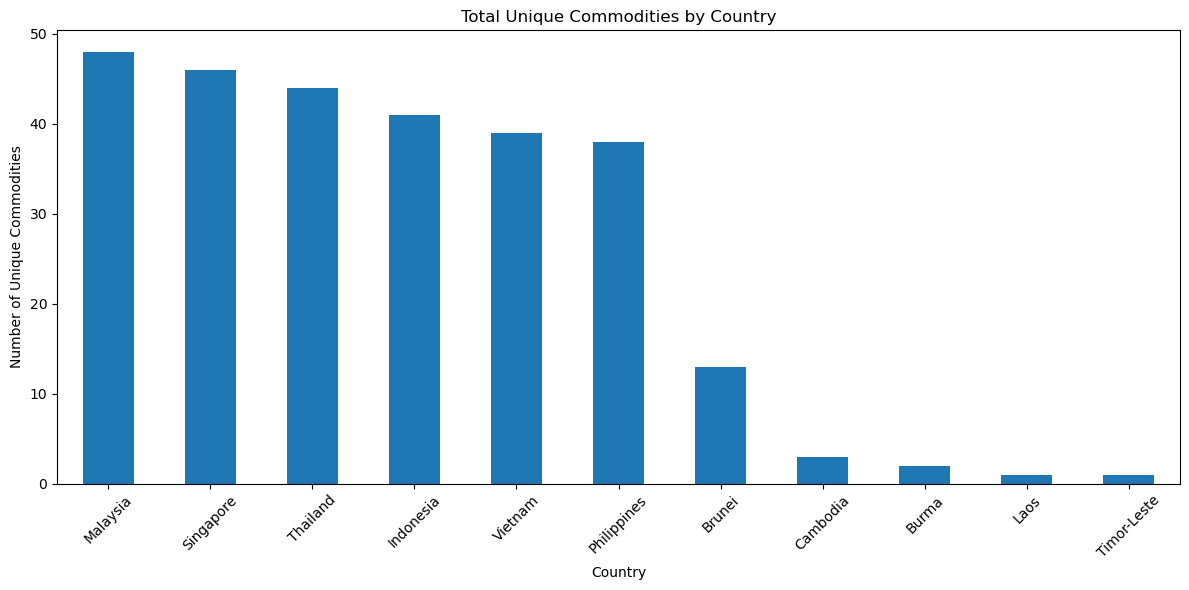

In [31]:
commodities_by_country = (
    df.groupby("Countries")["Commodities"]
    .nunique()
    .sort_values(ascending=False)
)

ax = commodities_by_country.plot(kind="bar")
ax.set_title("Total Unique Commodities by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Unique Commodities")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df["YearMonth"] = pd.to_datetime(df["YearMonth"])
df["YM"] = df["YearMonth"].dt.to_period("M")

# Function to find the longest continuous monthly streak
def max_consecutive_month_streak(periods):
    periods = sorted(pd.unique(periods))
    
    if len(periods) == 0:
        return 0, None, None
    
    ords = [p.ordinal for p in periods]
    
    best = 1
    current = 1
    best_start = periods[0]
    best_end = periods[0]
    current_start = periods[0]
    
    for i in range(1, len(periods)):
        if ords[i] == ords[i - 1] + 1:
            current += 1
        else:
            if current > best:
                best = current
                best_start = current_start
                best_end = periods[i - 1]
            current = 1
            current_start = periods[i]
    
    if current > best:
        best = current
        best_start = current_start
        best_end = periods[-1]
    
    return best, best_start, best_end

# Find country-commodity pairs with at least 5 continuous years
results = []

for (country, commodity), group in df.groupby(["Countries", "Commodities"]):
    months, start, end = max_consecutive_month_streak(group["YM"])
    
    if months >= 60:
        results.append({
            "Country": country,
            "Commodity": commodity,
            "Continuous_Months": months,
            "Continuous_Years": round(months / 12, 2),
            "Start": str(start),
            "End": str(end)
        })

continuous_df = pd.DataFrame(results).sort_values(["Commodity", "Country"])

# Print commodity -> countries
print("=" * 100)
print("CONTINUOUS COMMODITIES (5+ YEARS) AND THE COUNTRIES THAT TRADE THEM")
print("=" * 100)

commodity_countries = (
    continuous_df.groupby("Commodity")["Country"]
    .apply(list)
    .reset_index()
)

for _, row in commodity_countries.iterrows():
    print(f"\nCommodity: {row['Commodity']}")
    print("Countries:", ", ".join(row["Country"]))
    print("-" * 100)

# Print country -> commodities
print("\n" + "=" * 100)
print("COUNTRIES AND THEIR CONTINUOUS COMMODITIES (5+ YEARS)")
print("=" * 100)

country_commodities = (
    continuous_df.groupby("Country")["Commodity"]
    .apply(list)
    .reset_index()
)

for _, row in country_commodities.iterrows():
    print(f"\nCountry: {row['Country']}")
    for item in row["Commodity"]:
        print("-", item)
    print("-" * 100)

#detailed table at the end
print("\n" + "=" * 100)
print("DETAILED TABLE")
print("=" * 100)
print(continuous_df.to_string(index=False))

CONTINUOUS COMMODITIES (5+ YEARS) AND THE COUNTRIES THAT TRADE THEM

Commodity: 7505 Nickel Bars, Rods, Profiles And Wire
Countries: Singapore
----------------------------------------------------------------------------------------------------

Commodity: 7508 Articles Of Nickel, Nesoi
Countries: Malaysia, Singapore
----------------------------------------------------------------------------------------------------

Commodity: 7607 Aluminum Foil (back Or Not) Nov .2mm Th (ex Back)
Countries: Malaysia
----------------------------------------------------------------------------------------------------

Commodity: 7616 Articles Of Aluminum Nesoi
Countries: Malaysia, Singapore
----------------------------------------------------------------------------------------------------

Commodity: 8105 Cobalt Mattes Etc, Cobalt & Art, Inc Waste & Scrap
Countries: Singapore
----------------------------------------------------------------------------------------------------

Commodity: 8108 Titanium &

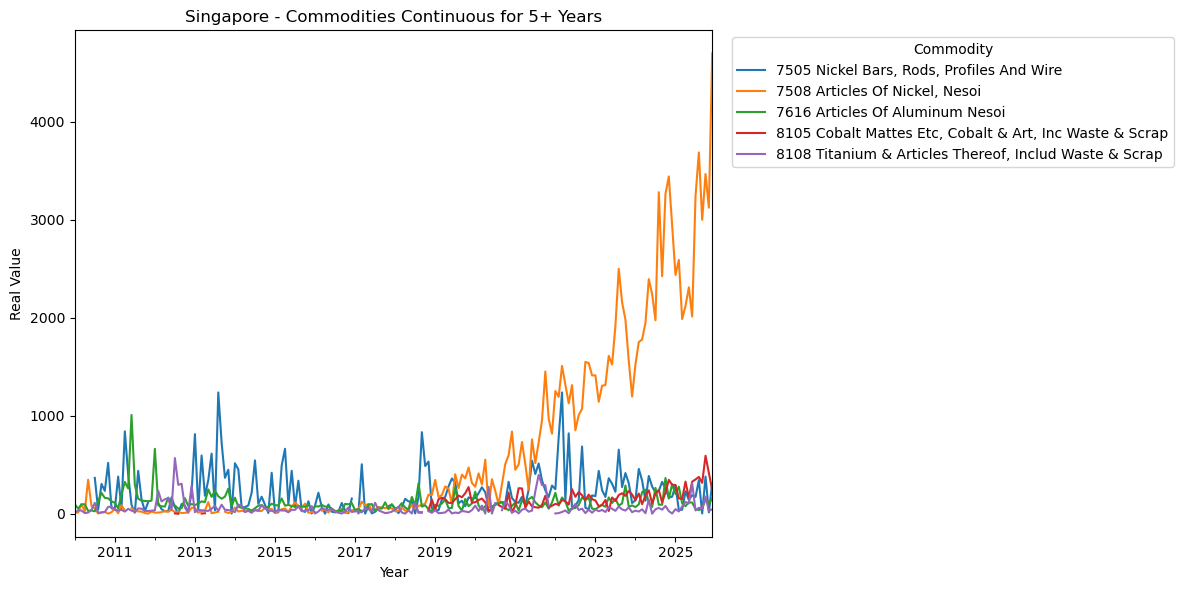

In [35]:
#just a helper df to display the y-axis in thousands 
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("retrospective_data_cleaned.csv")
df["YearMonth"] = pd.to_datetime(df["YearMonth"])

df["Real_Value_Thousands"] = df["Real_Value"] / 1000

singapore_commodities = [
    "7616 Articles Of Aluminum Nesoi",
    "7508 Articles Of Nickel, Nesoi",
    "8108 Titanium & Articles Thereof, Includ Waste & Scrap",
    "7505 Nickel Bars, Rods, Profiles And Wire",
    "8105 Cobalt Mattes Etc, Cobalt & Art, Inc Waste & Scrap"
]

singapore_df = df[
    (df["Countries"] == "Singapore") &
    (df["Commodities"].isin(singapore_commodities))
]

singapore_trend = (
    singapore_df.groupby(["YearMonth", "Commodities"])["Real_Value_Thousands"]
    .sum()
    .unstack()
    .sort_index()
)

singapore_trend.plot()
plt.title("Singapore - Commodities Continuous for 5+ Years")
plt.xlabel("Year")
plt.ylabel("Real Value")
plt.legend(title="Commodity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

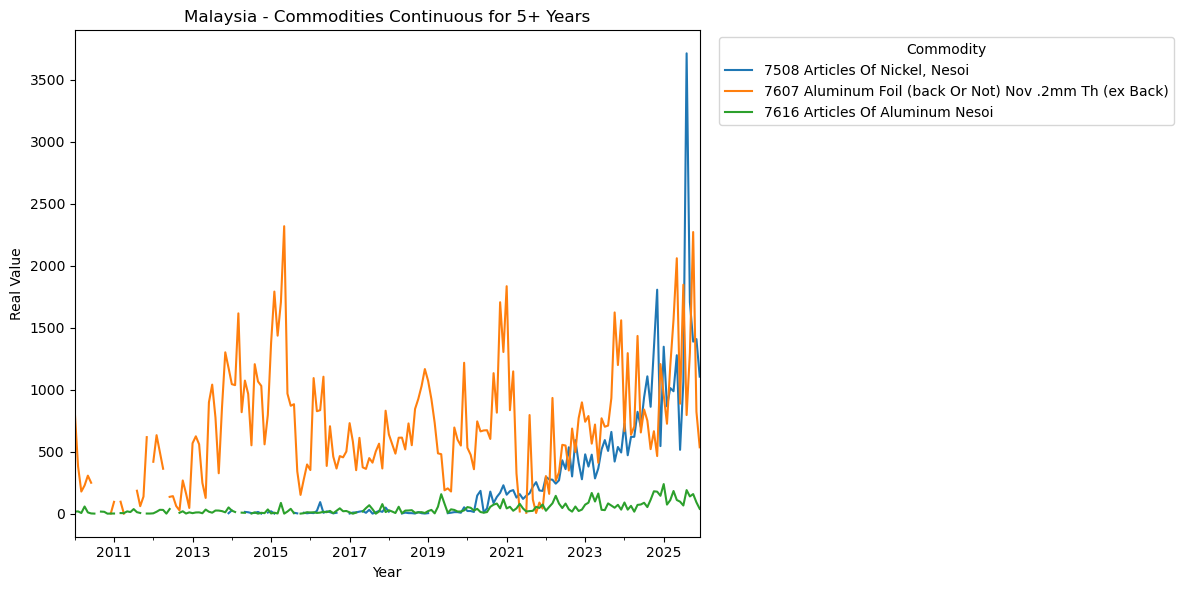

In [16]:
malaysia_commodities = [
    "7607 Aluminum Foil (back Or Not) Nov .2mm Th (ex Back)",
    "7616 Articles Of Aluminum Nesoi",
    "7508 Articles Of Nickel, Nesoi"
]

malaysia_df = df[
    (df["Countries"] == "Malaysia") &
    (df["Commodities"].isin(malaysia_commodities))
]

malaysia_trend = (
    malaysia_df.groupby(["YearMonth", "Commodities"])["Real_Value_Thousands"]
    .sum()
    .unstack()
    .sort_index()
)

malaysia_trend.plot()
plt.title("Malaysia - Commodities Continuous for 5+ Years")
plt.xlabel("Year")
plt.ylabel("Real Value")
plt.legend(title="Commodity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

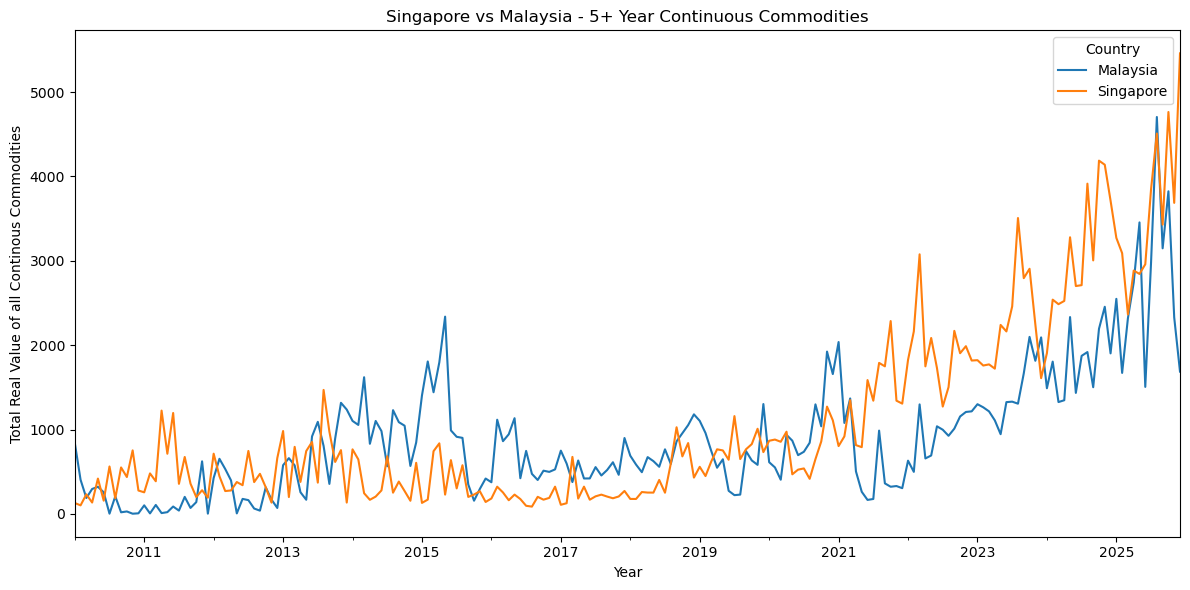

In [18]:
qualified_df = df[
    ((df["Countries"] == "Singapore") & (df["Commodities"].isin(singapore_commodities))) |
    ((df["Countries"] == "Malaysia") & (df["Commodities"].isin(malaysia_commodities)))
]

country_compare = (
    qualified_df.groupby(["YearMonth", "Countries"])["Real_Value_Thousands"]
    .sum()
    .unstack()
    .sort_index()
)

country_compare.plot()
plt.title("Singapore vs Malaysia - 5+ Year Continuous Commodities")
plt.xlabel("Year")
plt.ylabel("Total Real Value of all Continous Commodities")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

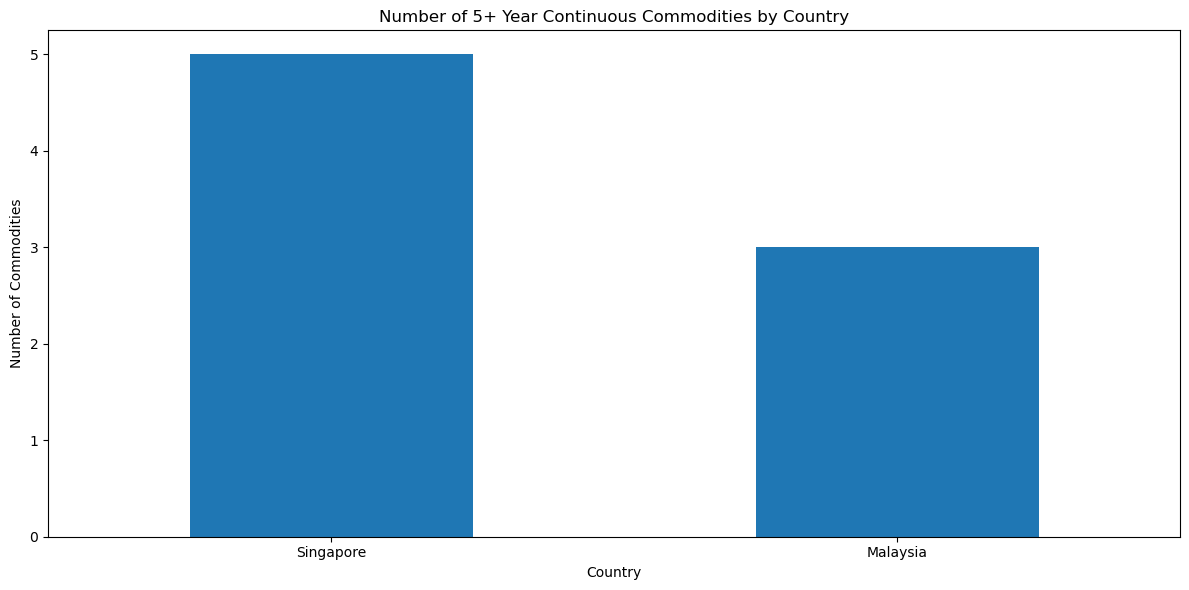

In [22]:
country_counts = pd.Series({
    "Singapore": 5,
    "Malaysia": 3
})

country_counts.plot(kind="bar")
plt.title("Number of 5+ Year Continuous Commodities by Country")
plt.xlabel("Country")
plt.ylabel("Number of Commodities")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

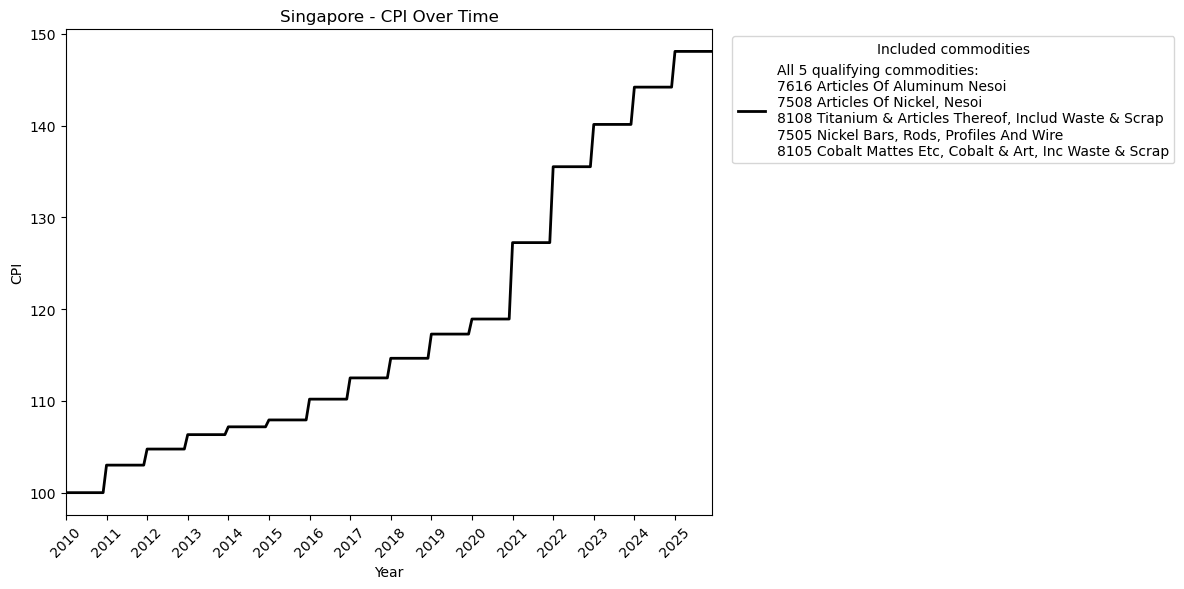

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("retrospective_data_cleaned.csv")
df["YearMonth"] = pd.to_datetime(df["YearMonth"])

singapore_commodities = [
    "7616 Articles Of Aluminum Nesoi",
    "7508 Articles Of Nickel, Nesoi",
    "8108 Titanium & Articles Thereof, Includ Waste & Scrap",
    "7505 Nickel Bars, Rods, Profiles And Wire",
    "8105 Cobalt Mattes Etc, Cobalt & Art, Inc Waste & Scrap"
]

singapore_df = df[
    (df["Countries"] == "Singapore") &
    (df["Commodities"].isin(singapore_commodities))
]

singapore_cpi = (
    singapore_df.groupby("YearMonth")["CPI"]
    .mean()
    .sort_index()
)

singapore_label = "All 5 qualifying commodities:\n" + "\n".join(singapore_commodities)

ax = singapore_cpi.plot(color="black", linewidth=2, label=singapore_label)

ax.set_title("Singapore - CPI Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("CPI")

# force year labels
years = pd.date_range(
    start=singapore_cpi.index.min(),
    end=singapore_cpi.index.max(),
    freq="YS"
)

ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

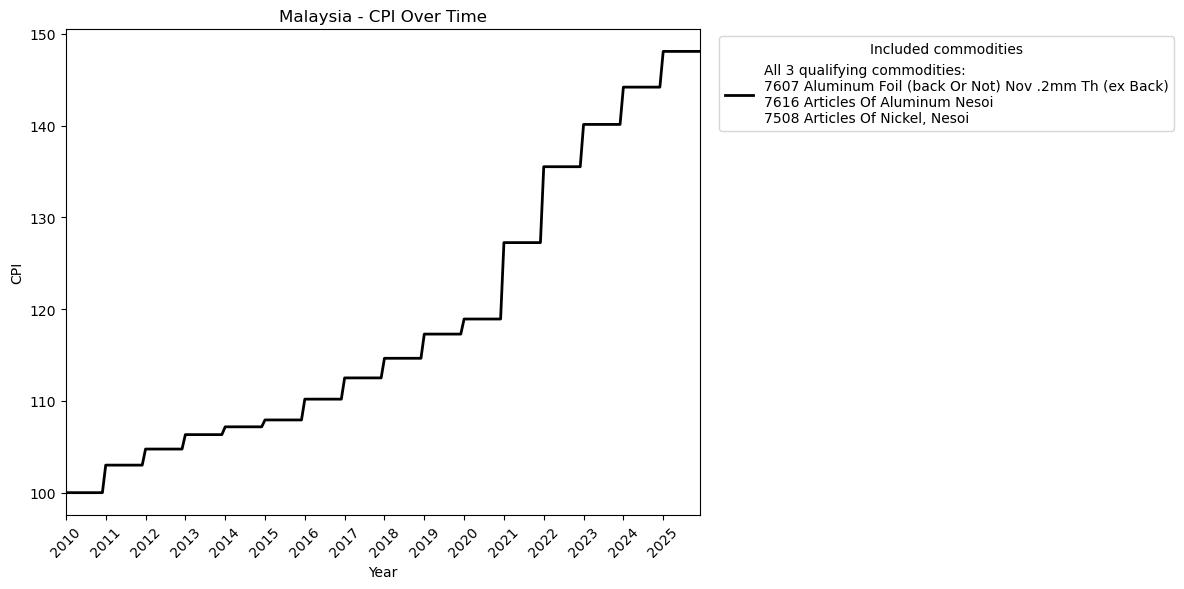

In [26]:
malaysia_commodities = [
    "7607 Aluminum Foil (back Or Not) Nov .2mm Th (ex Back)",
    "7616 Articles Of Aluminum Nesoi",
    "7508 Articles Of Nickel, Nesoi"
]

malaysia_df = df[
    (df["Countries"] == "Malaysia") &
    (df["Commodities"].isin(malaysia_commodities))
]

malaysia_cpi = (
    malaysia_df.groupby("YearMonth")["CPI"]
    .mean()
    .sort_index()
)

malaysia_label = "All 3 qualifying commodities:\n" + "\n".join(malaysia_commodities)

ax = malaysia_cpi.plot(color="black", linewidth=2, label=malaysia_label)

ax.set_title("Malaysia - CPI Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("CPI")

# force year labels
years = pd.date_range(
    start=malaysia_cpi.index.min(),
    end=malaysia_cpi.index.max(),
    freq="YS"
)

ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

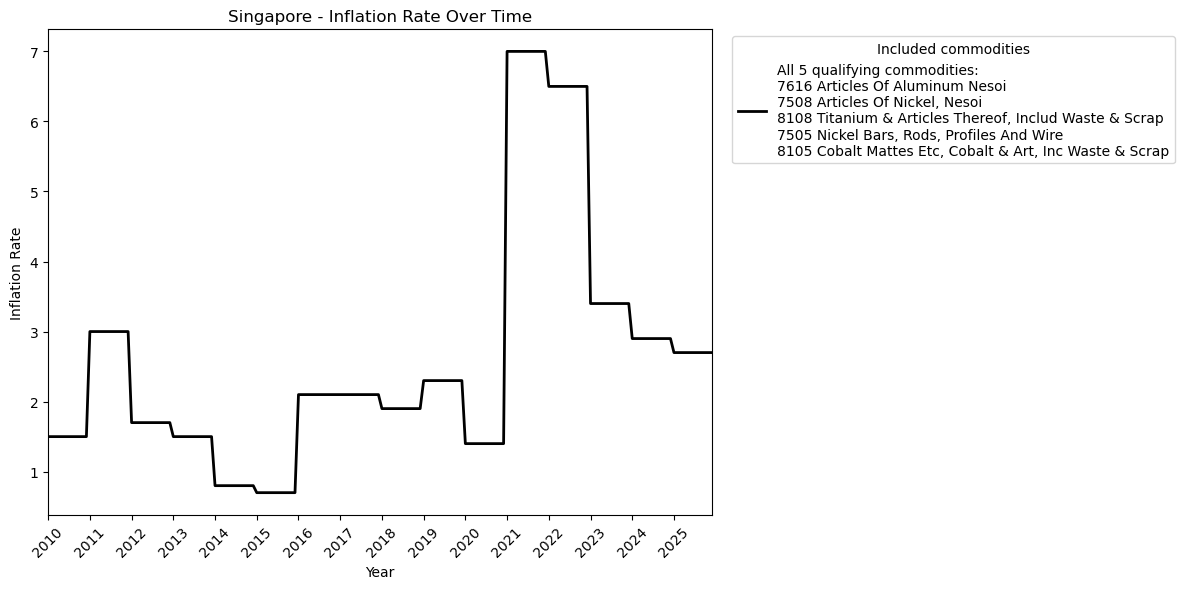

In [28]:
singapore_inflation = (
    singapore_df.groupby("YearMonth")["Inflation_Rate"]
    .mean()
    .sort_index()
)

singapore_label = "All 5 qualifying commodities:\n" + "\n".join(singapore_commodities)

ax = singapore_inflation.plot(color="black", linewidth=2, label=singapore_label)

ax.set_title("Singapore - Inflation Rate Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Inflation Rate")

years = pd.date_range(
    start=singapore_inflation.index.min(),
    end=singapore_inflation.index.max(),
    freq="YS"
)

ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

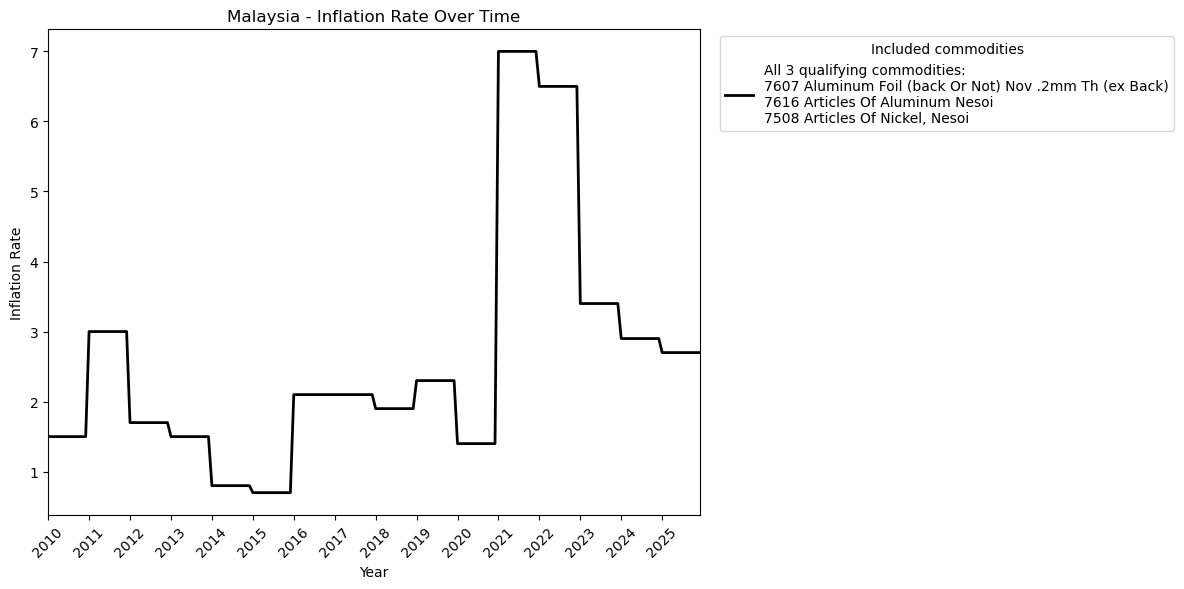

In [29]:
malaysia_inflation = (
    malaysia_df.groupby("YearMonth")["Inflation_Rate"]
    .mean()
    .sort_index()
)

malaysia_label = "All 3 qualifying commodities:\n" + "\n".join(malaysia_commodities)

ax = malaysia_inflation.plot(color="black", linewidth=2, label=malaysia_label)

ax.set_title("Malaysia - Inflation Rate Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Inflation Rate")

years = pd.date_range(
    start=malaysia_inflation.index.min(),
    end=malaysia_inflation.index.max(),
    freq="YS"
)

ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()